In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from read_gaukuk import ReadGaukuk
DEN = 0 
MTX = 1 
MTY = 2 
MTZ = 3 
ENG = 4 

In [46]:
frameID = 10
filename = "../bin/prim_" + str(frameID).zfill(5)
frame = ReadGaukuk(filename, isCons=False)
ib = frame.nGhost 
ie = frame.nGhost+frame.nx 

# print(frame.cons.shape)
print(frame.nGhost)

dx = frame.xc[1] - frame.xc[0]
xlist = np.linspace(frame.xc[0]-dx, frame.xc[-1]+dx, frame.lenx)

1


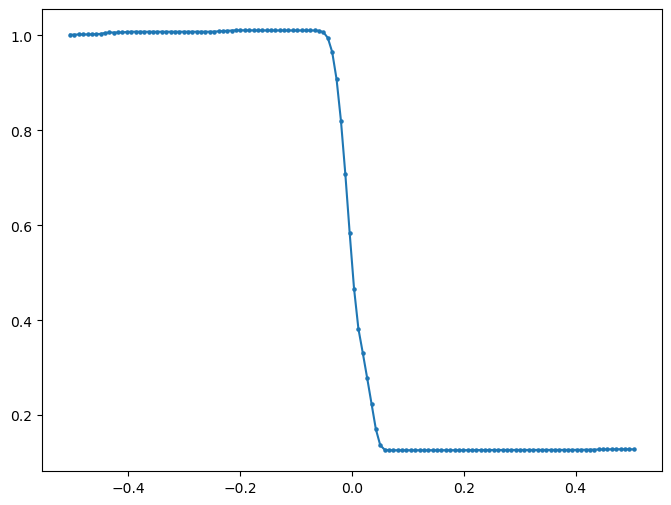

In [47]:
index = 0
ID = DEN 
k = 1
j = 1 
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
ax.plot(xlist[index:], frame.prim[ID,k,j,index:])
ax.scatter(xlist[index:], frame.prim[ID,k,j,index:], s = 5)
# ax.set_xlim(-0.6, 0.6)
plt.show()

In [25]:
index = 63
denl = frame.prim[DEN,k,j,index]
denr = frame.prim[DEN,k,j,index+1]
prel = frame.prim[ENG,k,j,index]
prer = frame.prim[ENG,k,j,index+1]
vxl = frame.prim[MTX,k,j,index]
vyr = frame.prim[MTX,k,j,index+1]
vyl = frame.prim[MTY,k,j,index]
vxr = frame.prim[MTY,k,j,index+1]
vzl = frame.prim[MTZ,k,j,index]
vzr = frame.prim[MTZ,k,j,index+1]
gamma = 1.4 
al = np.sqrt(gamma*prel/denl)
ar = np.sqrt(gamma*prer/denr)
prePVRS = 0.5*(prel + prer) - 0.125*(vxr - vxl)*(denl + denr)*(al + ar)

print(al, ar)
print("prePVRS: ", prePVRS)

gmRec = 1/gamma
temp = prePVRS/prel-1
ql = np.sqrt( 1 + 0.5*(1 + gmRec) * temp )
temp = prePVRS/prer-1
qr = np.sqrt( 1 + 0.5*(1 + gmRec) * temp ) 
print("ql, qr: ", ql, qr)

sl = vxl - al*ql; 
sr = vxr + ar*qr; 
ss = ( prer - prel + denl*vxl*(sl-vxl) - denr*vxr*(sr-vxr) ) / ( denl*(sl-vxl) - denr*(sr-vxr) ) 
print("sl, sr", sl, sr)
print("ss: ", ss)

1.816710241368154 1.8591532305932448
prePVRS:  2.1090789601008657
ql, qr:  1.0152194767439071 0.9984431715184727
sl, sr -1.8031509415756348 1.8562588478923339
ss:  -0.004677895178621757


In [36]:
gm1Rec = 1.0 / (gamma - 1.0)
el = prel*gm1Rec + 0.5*denl*(vxl*vxl+vyl*vyl+vzl*vzl)
er = prer*gm1Rec + 0.5*denr*(vxr*vxr+vyr*vyr+vzr*vzr)

cl = min(0.0, sl)*(ss-vxl)/(sl-ss)
cr = max(0.0, sr)*(ss-vxr)/(sr-ss)
if (ss>=0):
    selectl = 1.0 
else:
    selectl = 0
selectr = 1.0 - selectl

fl1 = denl * (vxl + cl) 
fl2 = denl * (vxl*vxl + cl*sl) + prel
fl3 = fl1*vyl                            
fl4 = fl1*vzl                             
fl5 = (el + prel)*(vxl + cl) + denl*cl*ss*(sl-vxl)

fr1 = denr * (vxr + cr)
fr2 = denr * (vxr*vxr + cr*sr) + prer
fr3 = fr1*vyr                        
fr4 = fr1*vzr                         
fr5 = (er + prer)*(vxr + cr) + denr*cr*ss*(sr-vxr)

f1 = selectl * fl1 + selectr * fr1
f2 = selectl * fl2 + selectr * fr2
f3 = selectl * fl3 + selectr * fr3
f4 = selectl * fl4 + selectr * fr4
f5 = selectl * fl5 + selectr * fr5

print(fl1)
print(fl2)
print(fl3)
print(fl4)
print(fl5)
print()
print(fr1)
print(fr2)
print(fr3)
print(fr4)
print(fr5)
print()
print(f1)
print(f2)
print(f3)
print(f4)
print(f5)

-0.004143555856327057
2.1093368095442004
-0.0
-0.0
-0.03453521108827339

-0.004000618818558281
2.1093361408997207
-0.001795575563141202
-0.0
-0.0349380648394771

-0.004000618818558281
2.1093361408997207
-0.001795575563141202
-0.0
-0.0349380648394771


In [ ]:
def ReadTArray(filename):
    with open(filename, "rb") as f:
        type= np.fromfile(f, dtype=np.int32, count=1)[0]
        size = np.fromfile(f, dtype=np.int32, count=1)[0] 
        dtype=np.float64
        if type== 8:
            dtype=np.float64
        elif type== 4:
            dtype=np.float32
        data = np.fromfile(f, dtype=dtype, count=size)
    return data

In [34]:
nVar = 5 
nx = 128
ny = 16
nz = 16 
nGhost = 1
lenx = nx + 2 * nGhost + 1
leny = ny + 2 * nGhost
lenz = nz + 2 * nGhost
lenArr = lenx * leny * lenz

path = "../bin/"
frameID = 3
filename = path + "flx1_"+str(frameID).zfill(5)
test = ReadTArray(filename)
test = test.reshape((nVar, lenz, leny, lenx))
print(test[0,9,5,:])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.04328115 0.33812061 0.25863468
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0. 

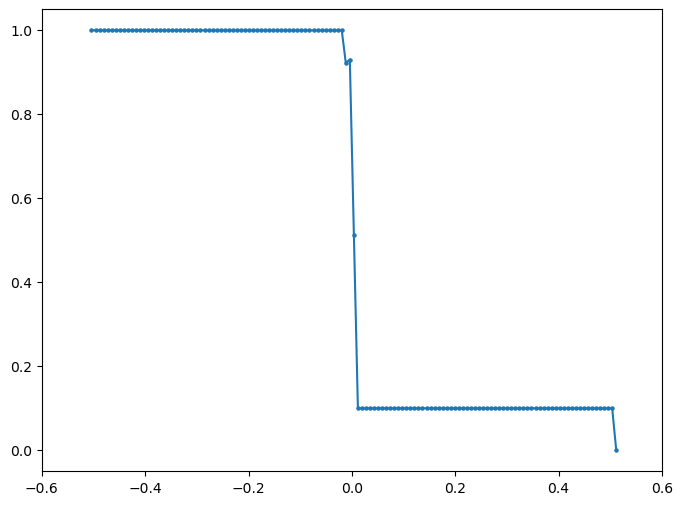

In [35]:
# frameID = 3
filename = path + "flx1_"+str(frameID).zfill(5)
test = ReadTArray(filename)
test = test.reshape((nVar, lenz, leny, lenx))

xlist = np.linspace(frame.xc[0]-dx, frame.xc[-1]+2*dx, frame.lenx+1)
ID = 1
k = 9
j = 5 
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
ax.plot(xlist, test[ID,k,j,:])
ax.scatter(xlist, test[ID,k,j,:], s = 5)
ax.set_xlim(-0.6, 0.6)
plt.show()

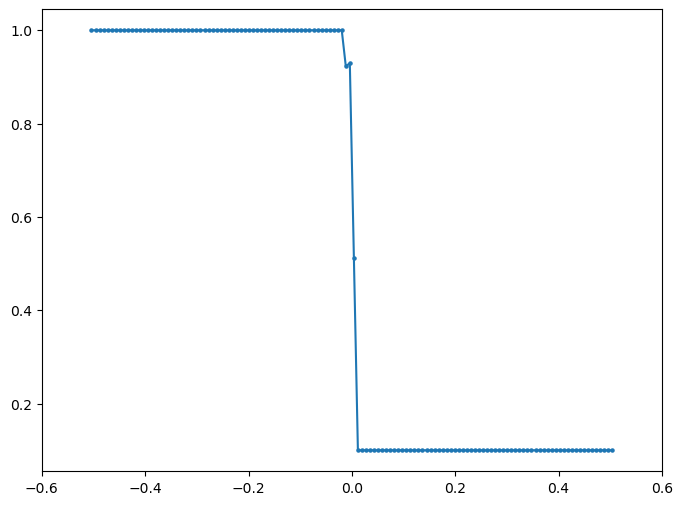

In [54]:
nVar = 5 
nx = 128
ny = 16
nz = 16 
nGhost = 1
lenx = nx + 2 * nGhost 
leny = ny + 2 * nGhost 
lenz = nz + 2 * nGhost + 1
lenArr = lenx * leny * lenz

path = "../bin/"
frameID = 3
filename = path + "flx3_"+str(frameID).zfill(5)
test = ReadTArray(filename)
test = test.reshape((nVar, lenz, leny, lenx))
# print(test[1,8,8,:])

xlist = np.linspace(frame.xc[0]-dx, frame.xc[-1]+dx, frame.lenx)
ID = 1
k = 9
j = 5 
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
ax.plot(xlist, test[ID,k,j,:])
ax.scatter(xlist, test[ID,k,j,:], s = 5)
ax.set_xlim(-0.6, 0.6)
plt.show()